In [1]:
import pandas as pd

In [2]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

/Users/tsuyos-u/Library/Caches/pypoetry/virtualenvs/semi-bayes-tseries-wVQtb5VF-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# def bass_model(t_values, season_index)

In [4]:
def bass_formula_model(t_values, season_indices, inventory_cap, sales_data=None, season_dim=4):
    # --- 1. パラメータ ---
    M = numpyro.sample("M", dist.LogNormal(jnp.log(5000), 0.1))
    
    # p, q の探索範囲（リパラメータ化推奨だが、一旦わかりやすく）
#    log_p = numpyro.sample("log_p", dist.Normal(-5.3, 1.0))
#    log_q = numpyro.sample("log_q", dist.Normal(-1.6, 0.5))

    p = numpyro.sample("p", dist.TruncatedNormal(0.005, 0.001, low=0.0))
    q = numpyro.sample("q", dist.TruncatedNormal(0.2, 0.01, low=0.0))

    # 決定論的変数として元のスケールに戻す
#    p = numpyro.deterministic("p", jnp.exp(log_p))
#    q = numpyro.deterministic("q", jnp.exp(log_q))
    
    with numpyro.plate("season_plate", season_dim):
        season_factors = numpyro.sample("season_factors", dist.LogNormal(0.0, 0.2))

#    with numpyro.plate("season_plate", season_dim):
        # まず制約なしでサンプリング
#        raw_season = numpyro.sample("raw_season", dist.LogNormal(0.0, 0.5))
    
    # 平均が 1.0 になるようにスケーリングする
    # これにより、bass_trend が「季節調整済みのトレンド」として正しく機能します
#    season_factors = numpyro.deterministic("season_factors", raw_season / jnp.mean(raw_season))    
    
    alpha = numpyro.sample("alpha", dist.Exponential(0.1))

    # --- 2. Bassモデルの解析解 (Closed Form) ---
    # 時刻 t における累積購入比率 F(t) の公式
    # F(t) = (1 - e^{-(p+q)t}) / (1 + (q/p)e^{-(p+q)t})
    
    # 時間 t の配列
    t = t_values 
    
    # m = p + q
    m = p + q
    
    # 指数部分の計算: exp(-(p+q)*t)
    exp_term = jnp.exp(-m * t)
    
    # 累積比率 F(t)
    # 分子: 1 - exp
    numerator = 1.0 - exp_term
    # 分母: 1 + (q/p)*exp
    denominator = 1.0 + (q / p) * exp_term
    
    F_t = numerator / denominator
    
    # 累積需要数 N(t) = M * F(t)
    N_t = M * F_t
    
    # その時点の新規需要 lambda(t) = N(t) - N(t-1)
    # jnp.diff で差分をとる。t=0 の分は N(0) そのもの。
    # 先頭に 0 を追加して差分をとるとサイズが合う
    N_padded = jnp.pad(N_t, (1, 0), constant_values=0.0)
    bass_trend = jnp.diff(N_padded)
    
    # --- 3. 季節性と尤度 (ここは同じ) ---
    current_season_factors = season_factors[season_indices]
    mu_t = bass_trend * current_season_factors
    mu_t = jnp.maximum(mu_t, 1e-6)

    if sales_data is not None:
        target_dist = dist.NegativeBinomial2(mean=mu_t, concentration=alpha)
        is_censored = (sales_data >= inventory_cap)
        log_prob_uncensored = target_dist.log_prob(sales_data)
        
        var_t = mu_t + (mu_t**2) / alpha
        sigma_t = jnp.sqrt(var_t)
        log_prob_censored = jax.scipy.stats.norm.logsf(inventory_cap - 0.5, loc=mu_t, scale=sigma_t)
        
        total_log_prob = jnp.where(is_censored, log_prob_censored, log_prob_uncensored)
        numpyro.factor("obs_log_prob", total_log_prob)
        numpyro.deterministic("mu_pred", mu_t)

In [5]:
# このモデルでWAICを計算できる？

In [6]:
# p, q, season_factor

In [7]:
def run_inference(data_t, data_season, data_inv, data_sales):
#     kernel = NUTS(bass_censored_model)
    kernel = NUTS(bass_formula_model)    
    mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000, num_chains=2)
    
    # ★追加: 探索のスタート地点を「良さそうな場所」に指定する
    # 実務では、過去の類似商品の平均値などを入れます
    init_values = {
        "M": jnp.array(5000.0),      # 真の値に近い値
        "p": jnp.array(0.005),       # 真の値に近い値
        "q": jnp.array(0.15),        # 真の値に近い値
        "alpha": jnp.array(10.0),    # 適当な値
        "season_factors": jnp.ones(4) # 季節係数も1.0からスタート
    }

    mcmc.run(
        jax.random.PRNGKey(0), 
        t_values=data_t, 
        season_indices=data_season,
        inventory_cap=data_inv,
        sales_data=data_sales,
        season_dim=4,  # ★修正: デフォルトの12ではなく、データの周期(4)を渡す
#        init_params=init_values # ★ここに追加
    )
    return mcmc

In [8]:
# 市場規模
# season_pattern - 1

In [9]:
T = 50
true_M = 5000
true_p = 0.005
true_q = 0.15
season_pattern = jnp.array([0.8, 1.2, 0.9, 1.1] * 13)[:T] # 4期周期

# 潜在需要生成
N = 0
true_demand = []
for t in range(T):
    lam = (true_M - N) * (true_p + true_q * (N / true_M)) * season_pattern[t]
    dem = numpyro.sample("d", dist.Poisson(lam), rng_key=jax.random.PRNGKey(t))
    true_demand.append(dem)
    N += lam # Bassモデルは期待値ベースで累積させる簡易版
true_demand = jnp.array(true_demand)

# 在庫制約の適用（わざと低く設定して打ち切りを作る）
inventory = jnp.full(T, 150) # 常に150個しか在庫がない
sales = jnp.minimum(true_demand, inventory)

print(f"Total Demand: {jnp.sum(true_demand)}, Total Sales: {jnp.sum(sales)}")
print(f"Censored ratio: {jnp.mean(sales == inventory):.2f}")

# 2. 推論実行
mcmc = run_inference(
    data_t=jnp.arange(T),
    data_season=jnp.arange(T) % 4, # 4期周期のインデックス
    data_inv=inventory,
    data_sales=sales
#    season_dim=4
)

Total Demand: 4918, Total Sales: 4366
Censored ratio: 0.26


/var/folders/fd/p9kv0qdj1xxg3_yflhhzj1b80000gn/T/ipykernel_52885/4197191939.py:4: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000, num_chains=2)
sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 3820.74it/s, 15 steps of size 2.67e-01. acc. prob=0.93]


<Axes: >

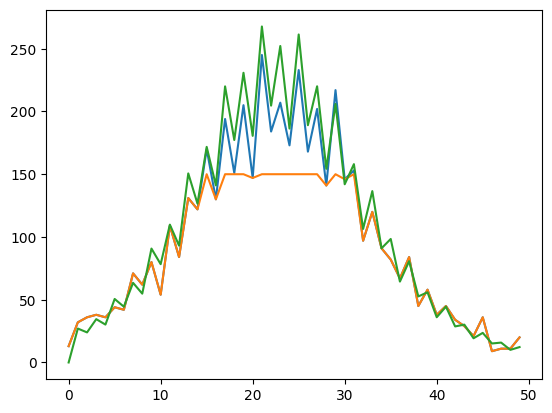

In [10]:
pd.Series(true_demand).plot()
pd.Series(sales).plot()
pd.DataFrame(mcmc.get_samples()['mu_pred']).median(axis=0).plot()
# pd.DataFrame(mcmc.get_samples()['mu_pred']).median(axis=0).plot()

In [11]:
# mcmc.get_samples()['p']
# mcmc.get_samples()['q']
# mcmc.get_samples()['M']

In [12]:
jnp.log(0.005)
true_q = 0.15